In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Change this to the parent directory if necessary
%cd /content/drive/MyDrive/2026 Deep Learning Bitcoin Fraud Detection

/content/drive/MyDrive/2026 Deep Learning Bitcoin Fraud Detection


In [3]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.1 MB/s eta 0:00:00


## The Elliptic Dataset (Transaction graph)

We pull the Elliptic dataset from the database, which is stored as a PyTorch multi-tensor. Then, we transform it into a PyTorch Geometric graph object and use NetworkX for visualization.

In [4]:
# Load the elliptic dataset
import torch
from torch_geometric.data import Data

elliptic = torch.load("./Dataset/processed/transaction_graph_v1.pt", weights_only=False, map_location="cpu")

elliptic

({'x': tensor([[ 1.0000e+00, -1.7147e-01, -1.8467e-01,  ..., -9.7524e-02,
           -1.2061e-01, -1.1979e-01],
          [ 1.0000e+00, -1.7148e-01, -1.8467e-01,  ..., -9.7524e-02,
           -1.2061e-01, -1.1979e-01],
          [ 1.0000e+00, -1.7211e-01, -1.8467e-01,  ..., -1.8367e-01,
           -1.2061e-01, -1.1979e-01],
          ...,
          [ 4.9000e+01, -1.7201e-01, -7.8182e-02,  ..., -9.7524e-02,
           -1.2061e-01, -1.1979e-01],
          [ 4.9000e+01, -1.7284e-01, -1.7662e-01,  ..., -1.4060e-01,
            1.5197e+00,  1.5214e+00],
          [ 4.9000e+01, -1.2037e-02, -1.3228e-01,  ..., -1.4060e-01,
            1.5197e+00,  1.5214e+00]]),
  'edge_index': tensor([[     0,      2,      4,  ..., 201921, 201480, 201954],
          [     1,      3,      5,  ..., 202042, 201368, 201756]]),
  'y': tensor([2, 2, 2,  ..., 1, 2, 2]),
  'train_mask': tensor([ True,  True,  True,  ..., False, False, False]),
  'val_mask': tensor([False, False, False,  ..., False, False, False]),
 

In [5]:
# Transform the dataset into a PyG (PyTorch Geometric) graph object
transaction_data = Data(**elliptic[0])

transaction_data

Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])

In [6]:
# Label 0 = licit, Label 1 = illict, Label 2 = unknown
labels = transaction_data.y

for label in [0, 1, 2]:
    pct = 100 * (labels == label).sum().item() / len(labels)
    print(f"Label {label}: {pct:.2f}%")

Label 0: 20.62%
Label 1: 2.23%
Label 2: 77.15%


The transaction graph is designed to be directed. However, here we consider its undirected version and use BFS (Breadth-First Search) to visualize a subgraph. In particular, we randomly select an illicit node and collect all nodes that can be reached `max_depth = 3` steps. A random seed is added so that the results are reproducible.

We use the undirected version rather than the directed one because it collects transactions both before and after the sampled one, yielding a complete local configuration of an illicit transaction. If we instead use the directed graph, the generated subgraph is most often just a single edge with three nodes, which has limited analytical value.

Starting from illicit node: 67681
Sub-graph nodes:108 


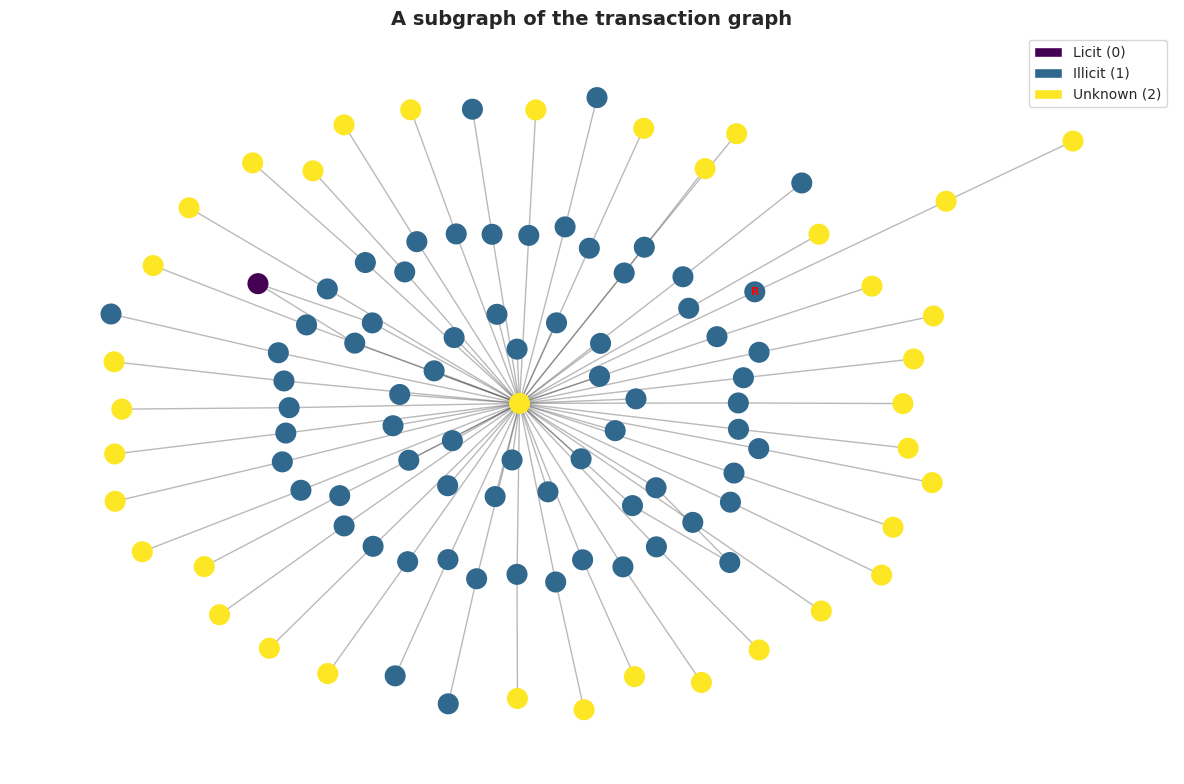

In [7]:
import networkx as nx
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from torch_geometric.utils.convert import to_networkx
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

# Create a networkx dataset for plotting
transaction_graph = to_networkx(transaction_data,to_undirected=True, node_attrs=['y'])


# Select a random illicit node as the root
seed = 42
np.random.seed(seed)

illicit_nodes = np.where(transaction_data.y.numpy() == 1)[0]
root = np.random.choice(illicit_nodes)
print(f"Starting from illicit node: {root}")

# Build subgraph using BFS with depth limit of 3
subgraph_nodes = list(nx.bfs_tree(transaction_graph, root, depth_limit=3).nodes())
subgraph = transaction_graph.subgraph(subgraph_nodes)

print(f"Sub-graph nodes:{len(subgraph.nodes())} ")

# Get node colors for the subgraph
node_labels = [subgraph.nodes[n]['y'] for n in subgraph.nodes()]

# Plot the network using seaborn
sns.set(style="white")
fig, ax = plt.subplots(figsize=(12, 8))
pos = nx.spring_layout(subgraph)

cmap = ListedColormap(["#440154", "#31688e", "#fde724"])

# Draw the network
nx.draw_networkx_nodes(subgraph, pos, node_color=node_labels, cmap=cmap, vmin = 0, vmax = 2, node_size=200, ax=ax)
nx.draw_networkx_edges(subgraph, pos, alpha=0.3, ax=ax)


# Add label to starting node
nx.draw_networkx_labels(subgraph, pos, labels={root: 'R'}, font_size=8, font_color='red', font_weight='bold', ax=ax)

# Create labels
legend_elements = [
    Patch(facecolor='#440154', label='Licit (0)'),
    Patch(facecolor='#31688e', label='Illicit (1)'),
    Patch(facecolor='#fde724', label='Unknown (2)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.title('A subgraph of the transaction graph', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('subgraph of the trasaction graph.png')
plt.show()

## The Elliptic++ Dataset (Actor-Transaction Graph)

We now pull the Elliptic++ dataset from our database (also as a multi-tensor).

In [8]:
# Load the Elliptic++ dataset and convert it to PyG graph object
from torch_geometric.data import HeteroData

elliptic_plus = torch.load("./Dataset/processed/transaction_actor_graph_v1.pt", weights_only=False, map_location="cpu")

actor_transaction_data = HeteroData()
for k, v in elliptic_plus[0].items():
  actor_transaction_data[k].update(v)
actor_transaction_data

HeteroData(
  _global_store={},
  wallets={
    x=[1268260, 55],
    y=[1268260],
    train_mask=[1268260],
    val_mask=[1268260],
    test_mask=[1268260],
  },
  transactions={
    x=[203769, 182],
    y=[203769],
    train_mask=[203769],
    val_mask=[203769],
    test_mask=[203769],
  },
  (transactions, to, transactions)={ edge_index=[2, 234355] },
  (transactions, to, wallets)={ edge_index=[2, 837124] },
  (wallets, to, transactions)={ edge_index=[2, 477117] },
  (wallets, to, wallets)={ edge_index=[2, 2868964] }
)

The graph is heterogeneous, meaning it contains two types of nodes: actors (wallets) and transactions. In the following code, we construct a directed graph that includes both types.

In [9]:
actor_transaction_graph = nx.DiGraph()

# Add actor nodes (wallets) and all their features
num_wallets = actor_transaction_data['wallets'].x.shape[0]
for i in range(num_wallets):
    actor_transaction_graph.add_node(i,
               node_type = 'actor',
               features = actor_transaction_data['wallets'].x[i],
               node_label = actor_transaction_data['wallets'].y[i].item(),
               train_mask = actor_transaction_data['wallets'].train_mask[i].item(),
               val_mask = actor_transaction_data['wallets'].val_mask[i].item(),
               test_mask = actor_transaction_data['wallets'].test_mask[i].item())

# Add transaction nodes and all their features
num_transactions = actor_transaction_data['transactions'].x.shape[0]
for i in range(num_transactions):
    actor_transaction_graph.add_node(i + num_wallets,
               node_type = 'transaction',
               features = actor_transaction_data['transactions'].x[i],
               node_label = actor_transaction_data['transactions'].y[i].item(),
               train_mask = actor_transaction_data['transactions'].train_mask[i].item(),
               val_mask = actor_transaction_data['transactions'].val_mask[i].item(),
               test_mask = actor_transaction_data['transactions'].test_mask[i].item())

# Add edges: wallet to wallet
edge_index = actor_transaction_data['wallets', 'to', 'wallets'].edge_index
edges_ww = [(int(edge_index[0, i]), int(edge_index[1, i])) for i in range(edge_index.shape[1])]
actor_transaction_graph.add_edges_from(edges_ww)

# Add edges: wallet to transaction
edge_index = actor_transaction_data['wallets', 'to', 'transactions'].edge_index
edges_wt = [(int(edge_index[0, i]), int(edge_index[1, i]) + num_wallets) for i in range(edge_index.shape[1])]
actor_transaction_graph.add_edges_from(edges_wt)

# Add edges: transaction to transaction
edge_index = actor_transaction_data['transactions', 'to', 'transactions'].edge_index
edges_tt = [(int(edge_index[0, i]) + num_wallets, int(edge_index[1, i]) + num_wallets) for i in range(edge_index.shape[1])]
actor_transaction_graph.add_edges_from(edges_tt)

# Add edges: transaction to wallet
edge_index = actor_transaction_data['transactions', 'to', 'wallets'].edge_index
edges_tw = [(int(edge_index[0, i]) + num_wallets, int(edge_index[1, i])) for i in range(edge_index.shape[1])]
actor_transaction_graph.add_edges_from(edges_tw)

print(f"Total nodes: {len(actor_transaction_graph.nodes())}, Total edges: {len(actor_transaction_graph.edges())}")

Total nodes: 1472029, Total edges: 4332940


We then visualize a subgraph. Here, we implelement a customized BFS algorithm which controls the number of nodes in the subgraph. The BFS will terminate once the number of nodes exceeds max_nodes = 50. Using different random seeds, we observe different behaviors. For some seeds, the sampled illicit node is isolated; for others, the resulting subgraph can contain more than 2,000 nodes.

Starting from illicit node: 762948
Sub-graph nodes:23 


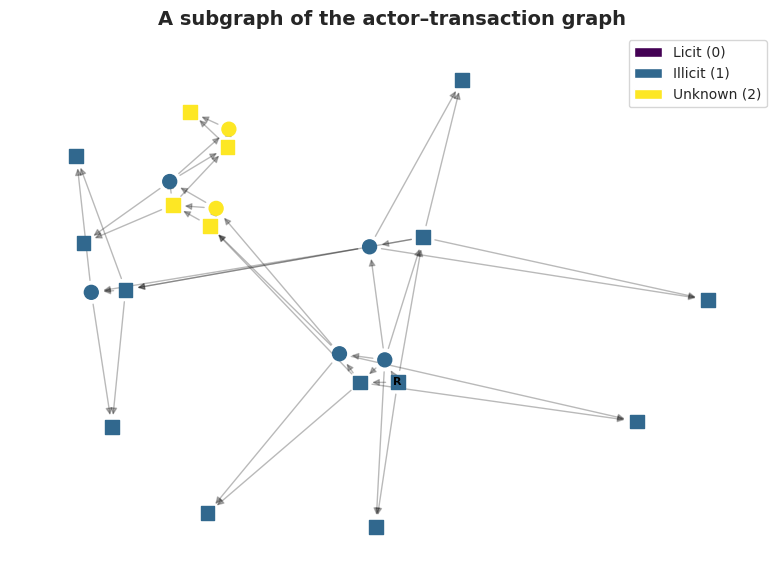

In [10]:
from collections import deque

seed = 58
np.random.seed(seed)

illicit_actors = np.where(actor_transaction_data['wallets'].y.numpy() == 1)[0]
root = np.random.choice(illicit_actors)
print(f"Starting from illicit node: {root}")

# Use BFS to find a subgraph (stop when number of nodes exceeds max_nodes)
max_nodes = 50
visited = set([root])
q = deque([root])

while q and len(visited) < max_nodes:
    curr = q.popleft()

    # Get neighbors
    neighbors = list(actor_transaction_graph.neighbors(curr))
    np.random.shuffle(neighbors)

    for node in neighbors:
        if node not in visited:
            q.append(node)
            visited.add(node)

subgraph = actor_transaction_graph.subgraph(list(visited))
print(f"Sub-graph nodes:{len(subgraph.nodes())} ")

# Separate nodes by type
actor_nodes = [n for n in subgraph.nodes() if actor_transaction_graph.nodes[n]['node_type'] == 'actor']
transaction_nodes = [n for n in subgraph.nodes() if actor_transaction_graph.nodes[n]['node_type'] == 'transaction']

# Colors
actor_colors = [actor_transaction_graph.nodes[n]['node_label'] for n in actor_nodes]
transaction_colors = [actor_transaction_graph.nodes[n]['node_label'] for n in transaction_nodes]

#Plot the subgraph
sns.set(style="white")
fig, ax = plt.subplots(figsize=(8,6))
pos = nx.spring_layout(subgraph)

cmap = ListedColormap(["#440154", "#31688e", "#fde724"])

# Draw actor nodes (square)
nx.draw_networkx_nodes(subgraph, pos, nodelist=actor_nodes, node_color=actor_colors, node_shape='s',cmap=cmap, vmin=0, vmax=2, node_size=100,ax=ax)

# Draw transaction nodes (circle)
nx.draw_networkx_nodes(subgraph, pos, nodelist=transaction_nodes, node_color=transaction_colors, node_shape='o',cmap=cmap, vmin=0, vmax=2, node_size=100,ax=ax)

# Draw edges
nx.draw_networkx_edges(subgraph, pos, alpha=0.3, ax=ax)
nx.draw_networkx_labels(subgraph, pos, labels={root: 'R'}, font_size=8, font_color='black', font_weight='bold',ax=ax)

legend_elements = [
    Patch(facecolor='#440154', label='Licit (0)'),
    Patch(facecolor='#31688e', label='Illicit (1)'),
    Patch(facecolor='#fde724', label='Unknown (2)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.title('A subgraph of the actor–transaction graph', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## Some EDA

In this section, we do some EDA using the original CSV files

In [11]:
# Read the CSV files that record node features and node classes
import pandas as pd
txs_df = pd.read_csv('./Dataset/raw/elliptic_bitcoin_dataset/elliptic_txs_features.csv', header= None)
labels_df = pd.read_csv('./Dataset/raw/elliptic_bitcoin_dataset/elliptic_txs_classes.csv')
edges_df = pd.read_csv('./Dataset/raw/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv')

In [12]:
txs_df.head()

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [13]:
labels_df.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [14]:
edges_df

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
234350,158365409,157930723
234351,188708874,188708879
234352,157659064,157659046
234353,87414554,106877725


In [15]:
# Assign column names to the feature dataframe
feature_cols = [f'f_{i}' for i in range(1, 166)]
cols = ['txId', 'time_step'] + feature_cols

txs_df.columns = cols
txs_df.head()

,txId,time_step,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,...,f_156,f_157,f_158,f_159,f_160,f_161,f_162,f_163,f_164,f_165
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


In [16]:
# Combine the feature and label dataframes together

joined_df = txs_df.merge(labels_df, on = 'txId', how = 'left')
joined_df

,txId,time_step,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,...,f_157,f_158,f_159,f_160,f_161,f_162,f_163,f_164,f_165,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.010822,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,-1.760926,-1.760984,unknown
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.985050,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,1
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.411776,1.461330,1.461369,-0.098889,-0.087490,-0.084674,-0.140597,1.519700,1.521399,unknown


We compute some basic statistics of the merged dataset. First, let’s look at the distribution of labels. Here, the labels are given as strings, where `'1'` represents illicit transactions and `'2'` represents licit transactions.

In [17]:
joined_df['class'].value_counts()

,count
class,
unknown,157205
2,42019
1,4545


Next, let's check whether the distribution of labels is uniform across all time steps.

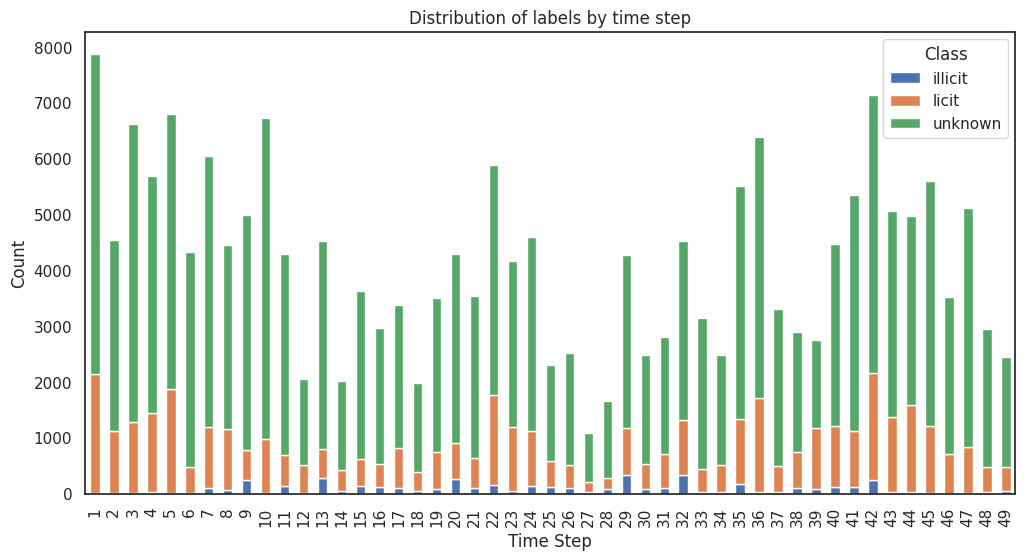

In [20]:
counts = (joined_df.groupby('time_step')['class']
          .value_counts()
          .unstack(fill_value=0))

counts = counts.rename(columns={'1':'illicit', '2':'licit', 'unknown':'unknown'})

counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Distribution of labels by time step')
plt.xlabel('Time Step')
plt.ylabel('Count')
plt.legend(title='Class')
plt.savefig('Distribution of labels by time step.png')
plt.show()

As we can see, the distribution of labels varies over time. This might potentially impact the performance of our prediction model.

Finally, let's plot the correlation heatmap for our features.

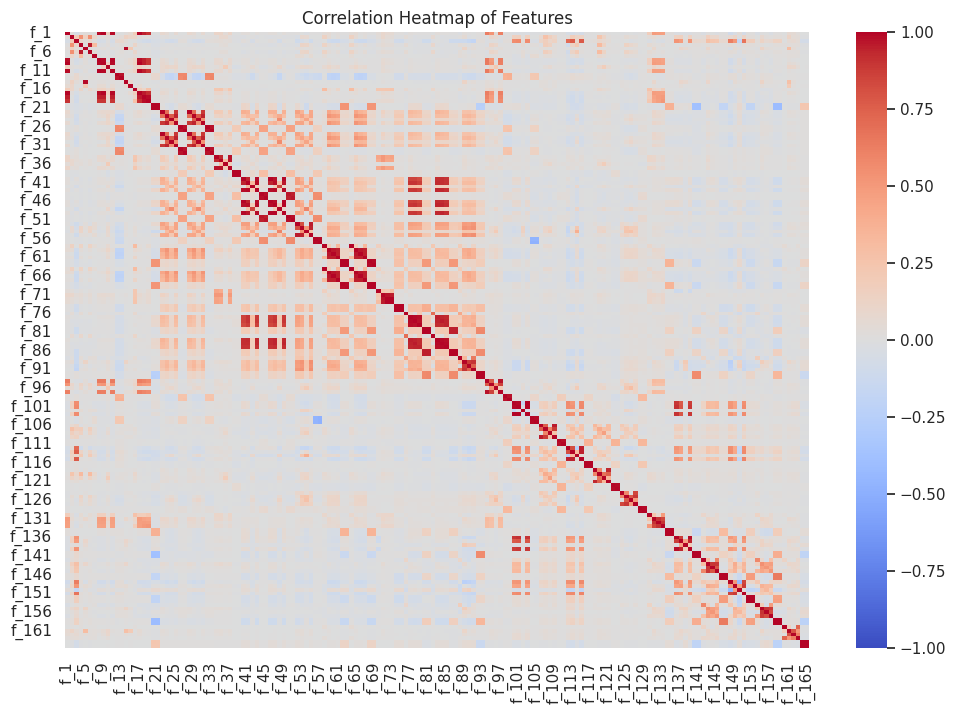

In [21]:
corr_matrix = joined_df[feature_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap of Features')
plt.savefig('Correlation Heatmap of Features.png')
plt.show()